# Faulty Medical Devices – Data Analysis

This notebook analyses a global dataset of faulty medical device events.  
The analysis demonstrates skills in:

- Data cleaning (dates, text normalisation, category fixing)
- Merging datasets (events, devices, manufacturers)
- Visualisation (Matplotlib, Seaborn)
- Post-Market Surveillance (PMS) insights
- Trend and category analysis

## Research Questions

1. What trends exist in faulty medical device events over time?
2. What notice types dominate global event data?
3. What action types are most frequent after cleaning?
4. Which countries report the most events?
5. How does data visualisation support PMS decision‑making?

In [3]:
import warnings
warnings.filterwarnings("ignore")

import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [5]:
# Load Data

# Set the full paths to the downloaded CSV files
events_path = r"C:/Users/williamsl/Downloads/archive/events-1681209680.csv"
devices_path = r"C:/Users/williamsl/Downloads/archive/devices-1681209661.csv"
manufacturers_path = r"C:/Users/williamsl/Downloads/archive/manufacturers-1681209657.csv"

# Load the datasets
events = pd.read_csv(events_path, low_memory=False)
devices = pd.read_csv(devices_path, low_memory=False)
manufacturers = pd.read_csv(manufacturers_path, low_memory=False)

events.head()

,id,action,action_classification,action_level,action_summary,authorities_link,country,create_date,data_notes,date,...,status,target_audience,type,uid,uid_hash,url,slug,device_id,created_at,updated_at
0,1,NaN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2016-04-04,...,NaN,NaN,Field Safety Notice,2016/294 & FA24MAR2016,41570514,https://web.archive.org/web/20170817053524/htt...,tur-cell-dyn-emerald-cleanser,1,2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC
1,2,NaN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2016-09-20,...,NaN,NaN,Field Safety Notice,2016/844 & FSCA2016-02,415f04f4,https://web.archive.org/web/20170817104322/htt...,tur-tecnis-monofocal-1-piece-tecnis-1-piece-io...,2,2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC
2,3,NaN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2016-05-09,...,NaN,NaN,Field Safety Notice,2016/437 & 2016018,2caa03df,https://web.archive.org/web/20170818050616/htt...,tur-centurion-fms-package-for-centurion-vision...,3,2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC
3,4,NaN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2016-12-19,...,NaN,NaN,Field Safety Notice,2016/1188 & 002/AS60130/17.00,666f0625,https://web.archive.org/web/20171014025042/htt...,tur-focusforce-intraocular-foldable-lenses,4,2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC
4,5,NaN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2017-02-20,...,NaN,NaN,Field Safety Notice,2017/242 & 02R06-21 / 02R06-31,6a8d063c,https://web.archive.org/web/20171014000531/htt...,tur-cholesterol-hdl-direct,5,2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC


In [6]:
# Clean Data

# Convert date column and restrict the dataset to a realistic timeframe
events["date"] = pd.to_datetime(events["date"], errors="coerce")
events = events[(events["date"] >= "1990-01-01") & (events["date"] <= "2026-12-31")]
events["year"] = events["date"].dt.year

# Basic text cleaning for selected fields
def clean_text(value):
    value = re.sub(r"[\x00-\x1f\x7f-\x9f]+", " ", str(value))
    return " ".join(value.split()).upper()

for df in (events, devices):
    for col in ["country", "type", "status", "action"]:
        if col in df.columns:
            df[col] = df[col].astype(str).map(clean_text)

events.head()

,id,action,action_classification,action_level,action_summary,authorities_link,country,create_date,data_notes,date,...,target_audience,type,uid,uid_hash,url,slug,device_id,created_at,updated_at,year
0,1,NAN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2016-04-04,...,NaN,FIELD SAFETY NOTICE,2016/294 & FA24MAR2016,41570514,https://web.archive.org/web/20170817053524/htt...,tur-cell-dyn-emerald-cleanser,1,2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC,2016
1,2,NAN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2016-09-20,...,NaN,FIELD SAFETY NOTICE,2016/844 & FSCA2016-02,415f04f4,https://web.archive.org/web/20170817104322/htt...,tur-tecnis-monofocal-1-piece-tecnis-1-piece-io...,2,2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC,2016
2,3,NAN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2016-05-09,...,NaN,FIELD SAFETY NOTICE,2016/437 & 2016018,2caa03df,https://web.archive.org/web/20170818050616/htt...,tur-centurion-fms-package-for-centurion-vision...,3,2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC,2016
3,4,NAN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2016-12-19,...,NaN,FIELD SAFETY NOTICE,2016/1188 & 002/AS60130/17.00,666f0625,https://web.archive.org/web/20171014025042/htt...,tur-focusforce-intraocular-foldable-lenses,4,2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC,2016
4,5,NAN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2017-02-20,...,NaN,FIELD SAFETY NOTICE,2017/242 & 02R06-21 / 02R06-31,6a8d063c,https://web.archive.org/web/20171014000531/htt...,tur-cholesterol-hdl-direct,5,2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC,2017


In [7]:
# Merge Events, Devices and Manufacturers

merged = events.merge(
    devices.add_prefix("dev_"),
    left_on="device_id",
    right_on="dev_id",
    how="left"
)

merged = merged.merge(
    manufacturers.add_prefix("mfr_"),
    left_on="dev_manufacturer_id",
    right_on="mfr_id",
    how="left"
)

merged.head()

,id,action,action_classification,action_level,action_summary,authorities_link,country,create_date,data_notes,date,...,mfr_id,mfr_address,mfr_comment,mfr_name,mfr_parent_company,mfr_representative,mfr_slug,mfr_source,mfr_created_at,mfr_updated_at
0,1,NAN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2016-04-04,...,1,NaN,“We are in constant communication with regulat...,Abbot Laboratories,Abbott Laboratories,NaN,turkey-drugs-and-medical-devices-agency-titck-...,Turkey Drugs and Medical Devices Agency (Titck),2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC
1,2,NAN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2016-09-20,...,2,NaN,NaN,Abbott Medical Optics (AMO) Inc.,Johnson & Johnson,NaN,turkey-drugs-and-medical-devices-agency-titck-...,Turkey Drugs and Medical Devices Agency (Titck),2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC
2,3,NAN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2016-05-09,...,3,NaN,NaN,Alcon Laboratories Inc.,Novartis Ag,NaN,turkey-drugs-and-medical-devices-agency-titck-...,Turkey Drugs and Medical Devices Agency (Titck),2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC
3,4,NAN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2016-12-19,...,4,NaN,NaN,ANADOLU TIP TEKNO.ÜRETİM PAZ.İTH İHRTİC SAN AŞ,NaN,NaN,turkey-drugs-and-medical-devices-agency-titck-...,Turkey Drugs and Medical Devices Agency (Titck),2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC
4,5,NAN,NaN,NaN,Recall,https://www.titck.gov.tr/,TUR,NaN,NaN,2017-02-20,...,5,NaN,NaN,ARCHEM SAĞLIK SANAYİ TİCARET LİMİTED ŞİRKETİ,NaN,NaN,turkey-drugs-and-medical-devices-agency-titck-...,Turkey Drugs and Medical Devices Agency (Titck),2022-08-04 08:28:00 UTC,2022-08-04 08:28:00 UTC


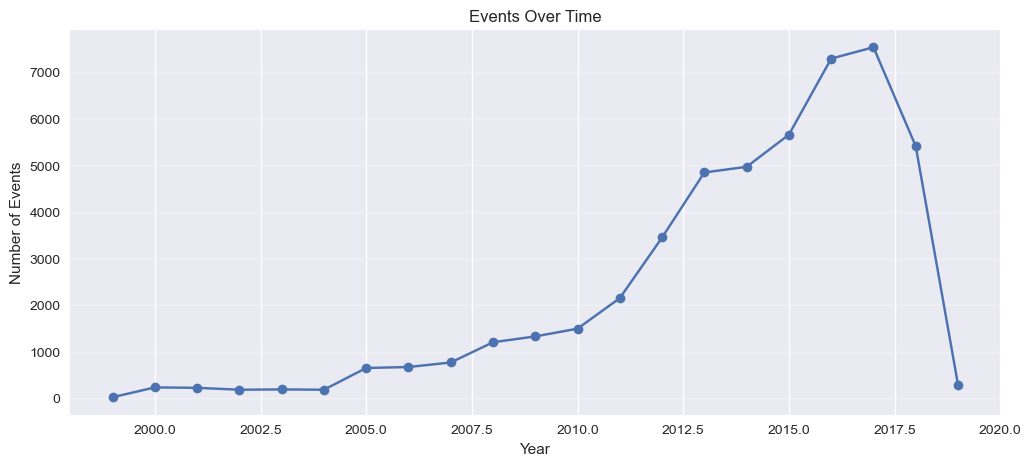

In [8]:
# Events Over Time

year_counts = merged["year"].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.title("Events Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.grid(axis="y", alpha=0.3)
plt.show()

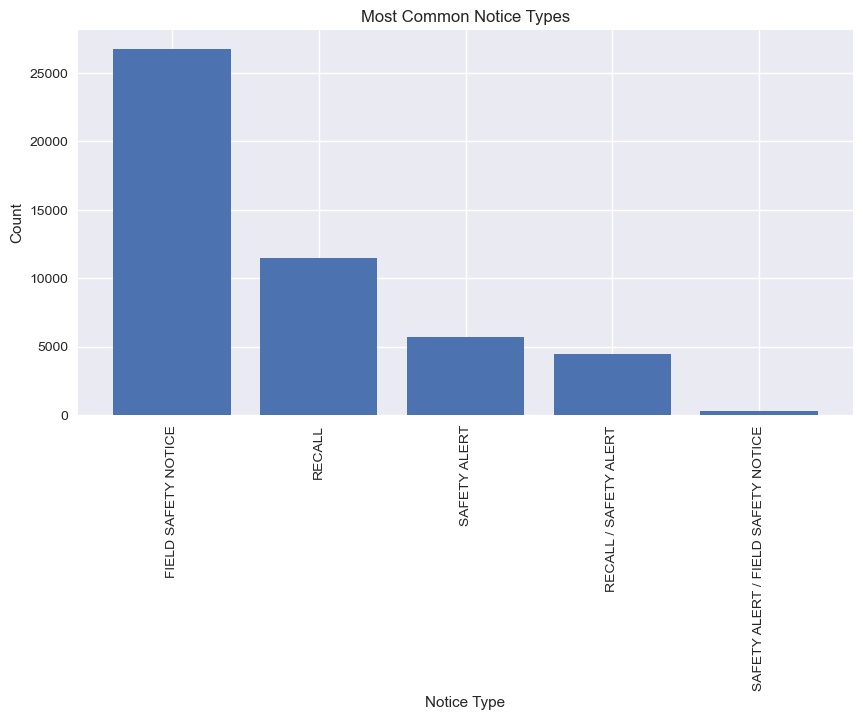

In [9]:
# Notice Types

type_counts = merged["type"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(type_counts.index, type_counts.values)
plt.xticks(rotation=90)
plt.title("Most Common Notice Types")
plt.xlabel("Notice Type")
plt.ylabel("Count")
plt.show()

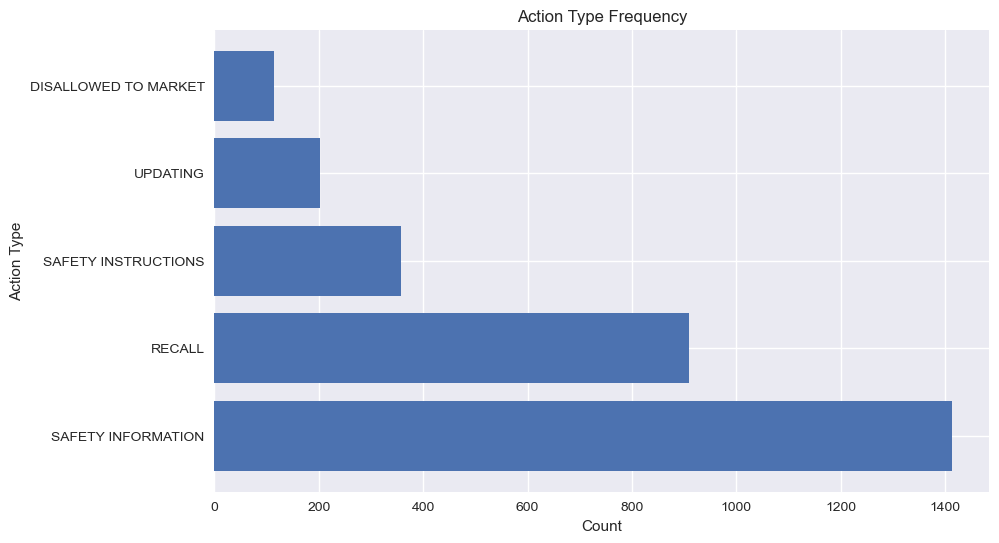

In [10]:
# Action Types (Cleaned)

valid_actions = {
    "RECALL",
    "SAFETY INFORMATION",
    "SAFETY INSTRUCTIONS",
    "UPDATING",
    "DISALLOWED TO MARKET"
}

merged["action_clean"] = merged["action"].map(clean_text)
action_totals = merged[merged["action_clean"].isin(valid_actions)]["action_clean"].value_counts()

plt.figure(figsize=(10,6))
plt.barh(action_totals.index, action_totals.values)
plt.title("Action Type Frequency")
plt.xlabel("Count")
plt.ylabel("Action Type")
plt.show()

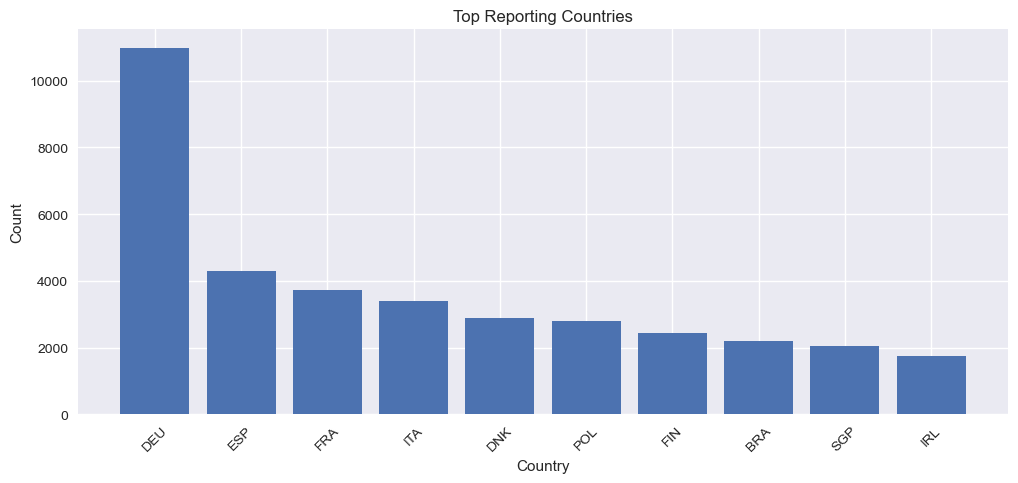

In [11]:
# Top Countries

country_counts = merged["country"].value_counts().head(10)

plt.figure(figsize=(12,5))
plt.bar(country_counts.index, country_counts.values)
plt.xticks(rotation=45)
plt.title("Top Reporting Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

# Interpretation

### Events Over Time
The number of reported events increases steadily from the early 2000s. This is likely linked to improvements in reporting systems and greater regulatory expectations over time.

### Notice Types
Field Safety Notices appear most frequently. These are usually issued before more significant regulatory actions and indicate early communication with the market.

### Action Types
Safety Information and Recalls make up the largest share of structured actions. This helps highlight which types of corrective or informative responses are used most often.

### Countries
Countries such as Germany, Spain, France, Italy and Denmark report the highest number of events. This may reflect strong national reporting systems and a high concentration of device manufacturers.

---

Overall, the dataset highlights clear trends in reporting activity and provides useful insights for post‑market surveillance and regulatory decision‑making.